In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time as time
import os
import sys
sys.path.append('..')
from scipy.optimize import curve_fit

# Nice colours
colorsBlue = ['#b3e5fc', '#0091ea']
colorsRed = ['#f18e86', '#e83b47']
colorsYellow = ['#fb9d32', '#fec787']
colorsPurple = ['#d69bc5' ,'#a8509f']
colorsGreyOrange = ['#c3c3c3', '#f8a834']
colors = [colorsBlue, colorsRed, colorsYellow, colorsPurple, colorsGreyOrange]

# Nice cmap
import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', [colors[0][1], 'white', colors[1][1]])

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from utils.dataset import GeneralDataset
from utils.network import MODELMixedModular

In [3]:
# basic settings
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encode_num = 4
decode_num = encode_num

Text(0, 0.5, 'f(x)')

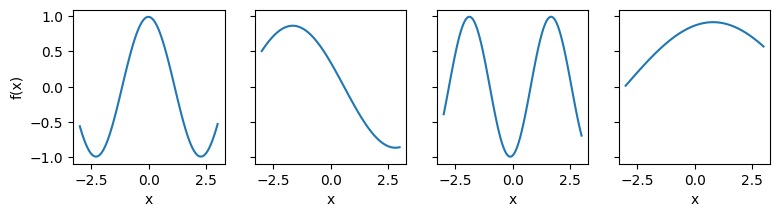

In [4]:
seed = 4
np.random.seed(seed)
torch.manual_seed(seed)

folder = f'results'
os.makedirs(folder, exist_ok = True)

amps = 0.7 + 0.3 * np.random.rand(encode_num) # * ((np.random.rand(encode_num) > 0) - 0.5)
fres = 0.4 + 1.4 * np.random.rand(encode_num) # 0.4, 0.4 for N8 and N16
phis = 2 * np.pi * np.random.rand(encode_num)
def morph(x):
    return amps * np.sin(fres * x + phis)
    
# plot to-be-learned functions
fig, axes = plt.subplots(1, encode_num, figsize = (9, 2), sharex = True, sharey = True)
xx = np.linspace(-3, 3, 100)
yy = np.array([morph([x] * encode_num) for x in xx])
for i in range(encode_num):
    axes[i].plot(xx, yy[:, i])
    axes[i].set_xlabel('x')
axes[0].set_ylabel('f(x)')

In [5]:
# training and test datasets
train_dataset = GeneralDataset(encode_num = encode_num, mapfun = morph, num_samples = 1000)
test_dataset = GeneralDataset(encode_num = encode_num, mapfun = morph, num_samples = 1000)
train_dataloader = DataLoader(train_dataset, batch_size = 50)

In [6]:
LOSS = []
models = []
for module_layer in [1, 2, 3, 4, 5]:
    print(f'simulating {module_layer}')

    hidden_num = 64
    module_layer = module_layer
    hidden_layer = 3
    module_size = 16
    
    models.append(MODELMixedModular(encode_num = encode_num,
                              decode_num = decode_num,
                              module_layer = module_layer,
                              hidden_layer = hidden_layer,
                              hidden_num = hidden_num,
                              module_size=module_size))
    models[-1].to(device)
    
    lr = 1e-4
    wd = 1e-5 # not using explicit L2 regularisation
    num_epochs = 2000
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(models[-1].parameters(), lr = lr, weight_decay = wd)
    
    # Training loop
    losses = []
    models[-1].train()
    for epoch in range(num_epochs):
        ls = models[-1].fit(train_dataloader, train_dataset, test_dataset, optimizer, criterion, device)
        losses.append(ls)
        print(f'epoch {epoch:07d}, test loss {losses[-1][0]:.5f}, valid vloss {losses[-1][1]:.5f}', end = '\r')
    losses = np.array(losses)
    print()
    LOSS.append([losses[-1, 0], losses[-1, 1]])
LOSS = np.array(LOSS)

simulating 1
epoch 0001999, test loss 0.00012, valid vloss 0.00019
simulating 2
epoch 0001999, test loss 0.00001, valid vloss 0.00002
simulating 3
epoch 0001999, test loss 0.00001, valid vloss 0.00001
simulating 4
epoch 0001999, test loss 0.00001, valid vloss 0.00002
simulating 5
epoch 0001999, test loss 0.00001, valid vloss 0.00002


In [8]:
# save model and loss
for i, module_layer in enumerate([1, 2, 3, 4, 5]):
    torch.save(models[i].state_dict(), os.path.join(folder, f'model_modbalance_L2_layer{module_layer}.pth'))
np.savetxt(os.path.join(folder, 'loss_modbalance_L2.txt'), LOSS)

In [9]:
# load model and loss
models = []
LOSS = []
for module_layer in [1, 2, 3, 4, 5]:
    print(f'loading model with module layer {module_layer}')
    model = MODELMixedModular(encode_num = encode_num,
                              decode_num = decode_num,
                              module_layer = module_layer,
                              hidden_layer = 3,
                              hidden_num = 64,
                              module_size=16)
    model.load_state_dict(torch.load(os.path.join(folder, f'model_modbalance_L2_layer{module_layer}.pth'), weights_only=False))
    model.to(device)
    models.append(model)
    
    loss = np.loadtxt(os.path.join(folder, 'loss_modbalance_L2.txt'))
    LOSS.append(loss[module_layer - 1])
LOSS = np.array(LOSS)

loading model with module layer 1
loading model with module layer 2
loading model with module layer 3
loading model with module layer 4
loading model with module layer 5


In [10]:
inputs, targets = test_dataset.get_all_data()
inputs, targets = inputs.to(device), targets.to(device)
ZZ, OUTS = [], []
for model in models:
    zz = []
    for i, modlyr in enumerate(model.modlayer):
        zz.append(modlyr(inputs[:, i].unsqueeze(-1)).detach().numpy())
    zz = np.array(zz)
    ZZ.append(zz)
    OUTS.append(model(inputs).detach().numpy())

In [11]:
def linear(x, a, b):
    return a * x + b

Layer 0, Encode 0, Prediction RMSE: 0.0464
Layer 0, Encode 1, Prediction RMSE: 0.1019
Layer 0, Encode 2, Prediction RMSE: 0.7242
Layer 0, Encode 3, Prediction RMSE: 0.0021
Layer 1, Encode 0, Prediction RMSE: 0.0280
Layer 1, Encode 1, Prediction RMSE: 0.0036
Layer 1, Encode 2, Prediction RMSE: 0.1707
Layer 1, Encode 3, Prediction RMSE: 0.0016
Layer 2, Encode 0, Prediction RMSE: 0.0060
Layer 2, Encode 1, Prediction RMSE: 0.0035
Layer 2, Encode 2, Prediction RMSE: 0.0204
Layer 2, Encode 3, Prediction RMSE: 0.0023
Layer 3, Encode 0, Prediction RMSE: 0.0306
Layer 3, Encode 1, Prediction RMSE: 0.0027
Layer 3, Encode 2, Prediction RMSE: 0.0138
Layer 3, Encode 3, Prediction RMSE: 0.0034
Layer 4, Encode 0, Prediction RMSE: 0.0025
Layer 4, Encode 1, Prediction RMSE: 0.0032
Layer 4, Encode 2, Prediction RMSE: 0.0182
Layer 4, Encode 3, Prediction RMSE: 0.0021


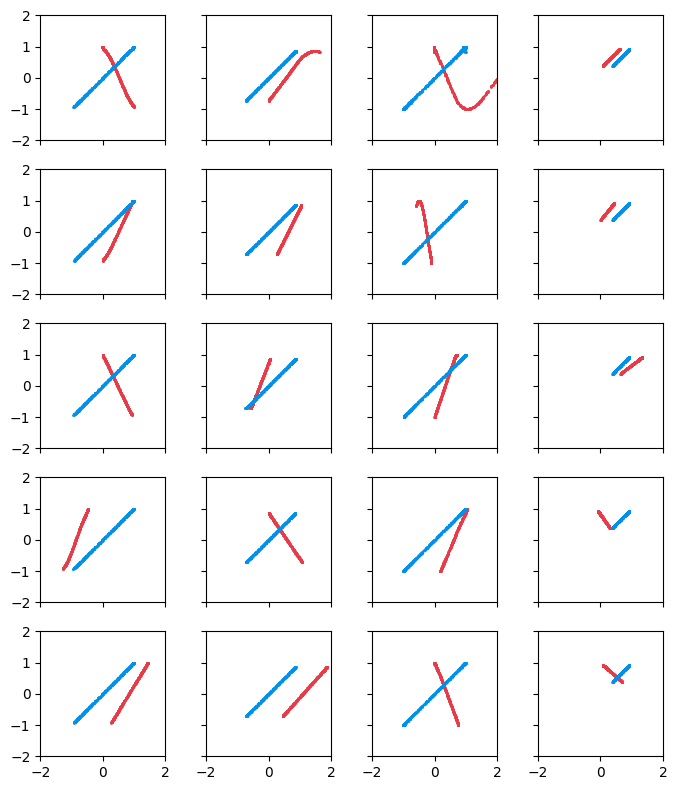

In [12]:
fig, axes = plt.subplots(len(models), encode_num, figsize = (7, 8), sharex = True, sharey = True)
xx = inputs.numpy() # np.linspace(-3, 3, 100)
yy = np.array([morph(x) for x in xx])
#a = [1.4,2,2.1,-1.4]
#b = [-0.8,-0.7,-1.0,0.8]
for j in range(len(models)):
    zz = ZZ[j]
    outputs = OUTS[j]
    for i in range(encode_num):
        #axes[i].plot(xx, yy[:, i])
        #axes[i].scatter(inputs[:, i], a[i] * zz[i] + b[i])
        _y = yy[:500, i]
        _z = zz[i,:500]
        _o = outputs[:500, i]
        axes[j, i].scatter(_z, _y, s = 1, color = colors[1][1], rasterized=True)
        axes[j, i].scatter(_o, _y, color = colors[0][1], s = 1, rasterized=True)
        popt, pcov = curve_fit(linear, np.reshape(zz[i], -1), yy[:, i])
        pred_error = np.sqrt(np.mean((linear(np.reshape(zz[i], -1), *popt) - yy[:, i])**2))
        print(f'Layer {j}, Encode {i}, Prediction RMSE: {pred_error:.4f}')
        # axes[j, i].plot([-2, 2], [-2, 2], color = 'black', linestyle = '--',zorder = -1)
        axes[j, i].set_xlim(-2, 2)
        axes[j, i].set_ylim(-2, 2)
        axes[j, i].set_aspect(1)
plt.tight_layout()
# plt.savefig('Mod4Fun.pdf')